## Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## Why this dataset matters

This dataset is historically important because it helped establish modern approaches for studying neural coding using:

- spike-triggered average (STA)
- spike-triggered covariance (STC)
- nonlinear receptive field estimation
- natural stimulus encoding models

It remains highly relevant today for comparing classical neuroscience methods with modern machine learning models such as GLMs, CNNs, and neural system identification networks.

Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.

For the `msq1D` white-noise experiments, the `.log` field `StiW` specifies the stimulus width on the display in centimeters. The viewing distance was 114 cm, so 1 cm corresponds to approximately 0.5° of visual angle. Since the stimulus contains 16 bars, the spatial width of each bar is `StiW / 16` cm (≈ `0.5 * StiW / 16` degrees). The stimulus coordinate system was aligned to each neuron's preferred orientation and direction.

When plotting STA/STC filters, label x-axis as:

Position (deg visual angle)

using StiW.

That makes the notebook publication-quality.

- imsq1D.mat = temporal sequence of bar patterns

From the dataset documentation:

msq1D.mat = 1D M-sequence stimulus with 16 bars, 32767 frames
imsq1D.mat = inverted M-sequence stimulus with 512 frames

This gives you:

X = stimulus matrix (known input)
y = spikes (neural output)

That is a supervised learning problem.

You can fit:

linear receptive fields
Poisson GLMs
CNNs
RNNs
temporal filters

In [1]:
from pathlib import Path
import numpy as np
from src import (retrieve_log, tori,
                 load_log_lines, numbers,
                 search_log, load_spikes)

from scipy.io import loadmat
import os
import matplotlib.pyplot as plt

### settings for the project

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_ROOT    = PROJECT_ROOT          # data lives directly under project root
root         = DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"

the first priority after isolating a neuron is to determine what kind of stimulus drives it best. The tuning run is therefore usually performed first as a calibration and characterization step.

For V1 neurons, especially in cat primary visual cortex, responses depend strongly on stimulus orientation, spatial frequency, position, contrast, and motion. If you do not know these preferences first, later experiments may be inefficient or even misleading.



In [3]:
def is_it_complex(directory, plot=False):
    for folder in sorted(os.listdir(directory)):
        folder_path = os.path.join(directory, folder)

        tune_logs = [
            f for f in os.listdir(folder_path)
            if f.endswith("tune.log")
        ]
        if not tune_logs:
            continue

        first_file = sorted(tune_logs)[0]

        try:
            flog = retrieve_log(path=root / folder, filename=first_file, channels=None)
            info = tori(flog, cluster_index=0, plot=plot)
        except (ValueError, IndexError):
            continue

        relmod = info["relmod"]
        cell_type = "simple / linear-like" if relmod > 1.0 else "complex / nonlinear-like"
        print(f"cell {first_file} is {cell_type}, relmod = {relmod:.4f}")


is_it_complex(root)

cell 000412.a01atune.log is complex / nonlinear-like, relmod = 0.3333
cell 000413.b03atune.log is complex / nonlinear-like, relmod = 0.7116
cell 000413.b04atune.log is complex / nonlinear-like, relmod = 0.2134
cell 000413.b05atune.log is complex / nonlinear-like, relmod = 0.1971
cell 000418.a01atune.log is complex / nonlinear-like, relmod = 0.7083
cell 000419.a06gtune.log is complex / nonlinear-like, relmod = 0.3059
cell 000419.a07atune.log is complex / nonlinear-like, relmod = 0.5679
cell 000419.a09itune.log is complex / nonlinear-like, relmod = 0.4275
cell 000420.b02atune.log is simple / linear-like, relmod = 1.8052
cell 000503.a03atune.log is complex / nonlinear-like, relmod = 0.2938
cell 000511.b09ntune.log is complex / nonlinear-like, relmod = 0.5019
cell 000511.b10otune.log is complex / nonlinear-like, relmod = 0.3234
Correcting spike file: 000512.d11atune.sa0 -> 000513.d11atune.sa0
cell 000513.d11atune.log is complex / nonlinear-like, relmod = 0.1176
cell 000524.c01atune.log is 

cell 010322.A.f06atune.log is complex / nonlinear-like, relmod = 0.0954
cell 010524.A.f01atune.log is complex / nonlinear-like, relmod = 0.2061
cell 010612.B.b02atune.log is complex / nonlinear-like, relmod = 0.2772
cell 010614.B.e08atune.log is complex / nonlinear-like, relmod = 0.1829
cell 010628.A.c03atune.log is complex / nonlinear-like, relmod = 0.2552
cell 010628.A.c04atune.log is complex / nonlinear-like, relmod = 0.6071
cell 010718.B.c01atune.log is complex / nonlinear-like, relmod = 0.8395


cell 010718.B.c02atune.log is complex / nonlinear-like, relmod = 0.2785
cell 010801.A.b01dtune.log is simple / linear-like, relmod = 1.1081
cell 011019.A.c09atune.log is complex / nonlinear-like, relmod = 0.2963
cell 011024.A.b04atune.log is complex / nonlinear-like, relmod = 0.0604
cell 011025.A.d07atune.log is complex / nonlinear-like, relmod = 0.1598
cell 011101.A.d02atune.log is complex / nonlinear-like, relmod = 0.2354
cell 011101.A.d03atune.log is complex / nonlinear-like, relmod = 0.1987


cell 011121.A.d02atune.log is complex / nonlinear-like, relmod = 0.1252
cell 020109.A.b01atune.log is complex / nonlinear-like, relmod = 0.4188
cell 020109.A.b02atune.log is complex / nonlinear-like, relmod = 0.1536
cell 020213.A.i01atune.log is complex / nonlinear-like, relmod = 0.6928
cell 020214.A.j01atune.log is complex / nonlinear-like, relmod = 0.9089
cell 020306.A.a01atune.log is complex / nonlinear-like, relmod = 0.6096
cell 020306.A.a02atune.log is complex / nonlinear-like, relmod = 0.3110
cell 020308.A.d01atune.log is complex / nonlinear-like, relmod = 0.4369


cell 020321.A.i01atune.log is complex / nonlinear-like, relmod = 0.1279
cell 020321.A.i02atune.log is complex / nonlinear-like, relmod = 0.2105


In [4]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH=root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]


filenames_linear=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'

]


paths_comples_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial = [LINEAR_NEURON_PATH / name for name in filenames_linear]






### neuron b03 of 2000

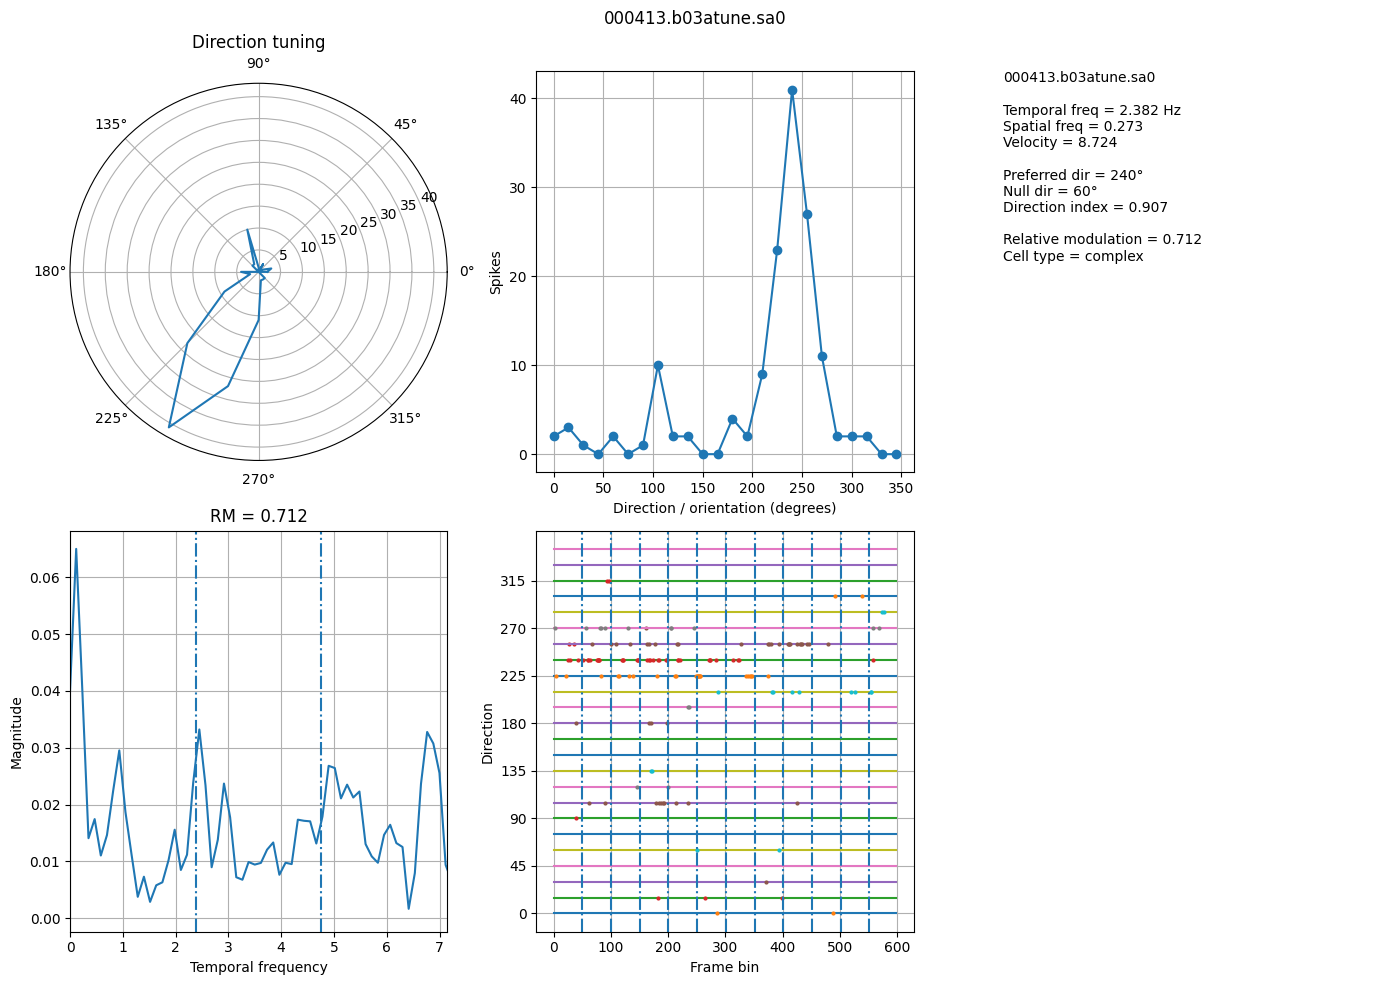

In [5]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)




In [6]:

for path in paths_comples_trials:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    print(f'Stimulus: {msq1D_stim.shape}  (frames × bars)')
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

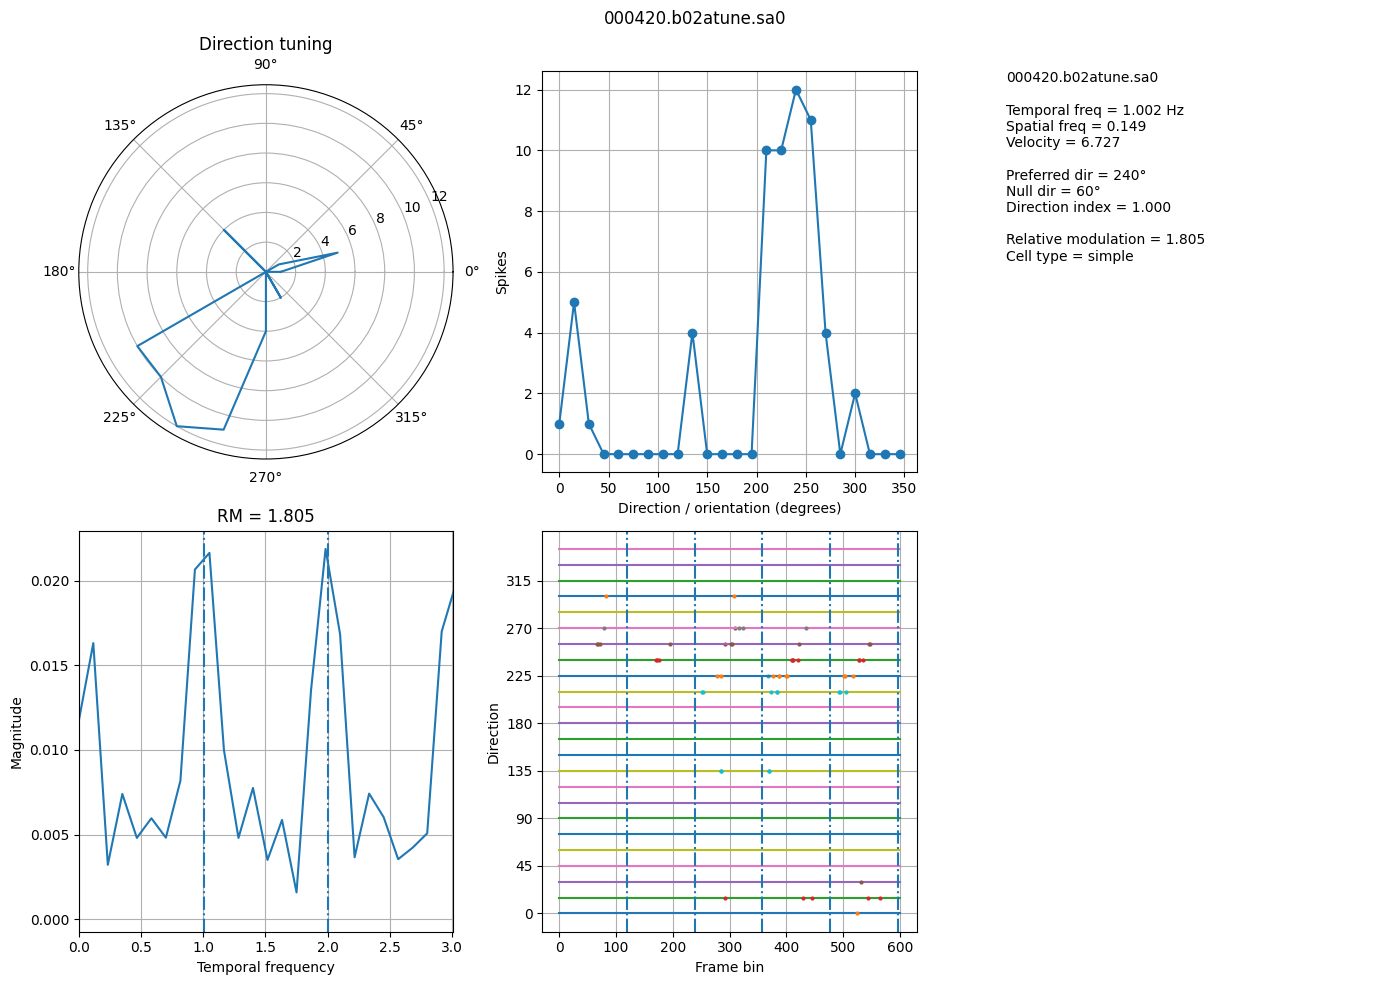

In [7]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH / name for name in filenames_complex]


msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1




In [8]:
for path in paths_linear_trial:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    print(f'Stimulus: {msq1D_stim.shape}  (frames × bars)')
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


In [9]:
from pathlib import Path
import numpy as np
import struct


SPK_HEADER_SIZE = 828


def _read_c_string(raw: bytes) -> str:
    """
    Decode fixed-width MATLAB-style char fields.
    Removes trailing nulls, spaces, and newlines.
    """
    return raw.split(b"\x00", 1)[0].decode("ascii", errors="replace").strip()


def fget_hdr_python(path):
    path = Path(path)
    raw = path.read_bytes()

    if len(raw) < SPK_HEADER_SIZE:
        raise ValueError(f"{path.name}: file is too small to contain a full header")

    pos = 0

    def read_chars(n):
        nonlocal pos
        out = _read_c_string(raw[pos:pos + n])
        pos += n
        return out

    def read_int32():
        nonlocal pos
        value = struct.unpack_from("<i", raw, pos)[0]
        pos += 4
        return value

    file_info = {
        "Type": read_chars(16),
        "Version": read_chars(16),
        "Fname": read_chars(128),
        "Creator": read_chars(128),
        "Time": read_chars(32),
    }

    if file_info["Type"] != "DAN_SPK":
        raise ValueError(f"{path.name}: bad file type {file_info['Type']!r}")

    pos += 64  # reserved

    data_info = {
        "ID": read_chars(128),
        "DataFrom": read_chars(128),
        "Channel": read_int32(),
        "SampleRate": read_int32(),
        "Gain": read_int32(),
        "DAQMode": read_int32(),
        "DAQResolution": read_int32(),
        "DataType": read_int32(),
        "DataUnit": read_int32(),
        "TimeMode": read_int32(),
        "TimeOffset": read_int32(),
        "ThreshPeakHigh": read_int32(),
        "ThreshPeakLow": read_int32(),
        "ThreshValleyHigh": read_int32(),
        "ThreshValleyLow": read_int32(),
        "ThreshWidthMax": read_int32(),
        "ThreshWidthMin": read_int32(),
    }

    pos += 128  # reserved

    assert pos == SPK_HEADER_SIZE

    return {
        "FileInfo": file_info,
        "DataInfo": data_info,
    }

def fget_spk_python(path, sample_rate=None, return_header=True):
    path = Path(path)
    raw = path.read_bytes()

    name = path.name.lower()

    if "mq" in name or "film02" in name or "film32" in name:
        dtype = np.dtype("<u4")  # MATLAB uint32, little-endian
    else:
        dtype = np.dtype("<i4")  # MATLAB int32, little-endian

    has_header = b"DAN_SPK" in raw[:16]

    if has_header:
        hdr = fget_hdr_python(path)
        events = np.frombuffer(raw[SPK_HEADER_SIZE:], dtype=dtype)
    else:
        hdr = None
        events = np.frombuffer(raw, dtype=dtype)

    if sample_rate is None:
        if hdr is not None and hdr["DataInfo"]["SampleRate"] > 0:
            sample_rate = hdr["DataInfo"]["SampleRate"]
        else:
            sample_rate = 10000

    spike_times_sec = events.astype(float) / sample_rate

    if return_header:
        return events, spike_times_sec, hdr
    else:
        return events, spike_times_sec

Spike count: 583
First 10 events: [  3914   3930  40481  42780  44460  44489  83092 115928 159197 166355]


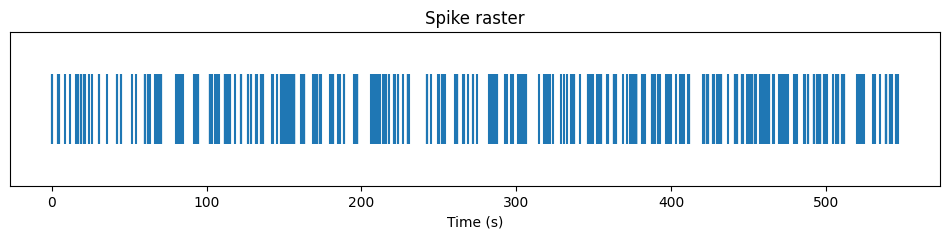

Spike count: 645
First 10 events: [ 75726 102368 259150 262400 270362 309654 315127 316941 317004 333238]


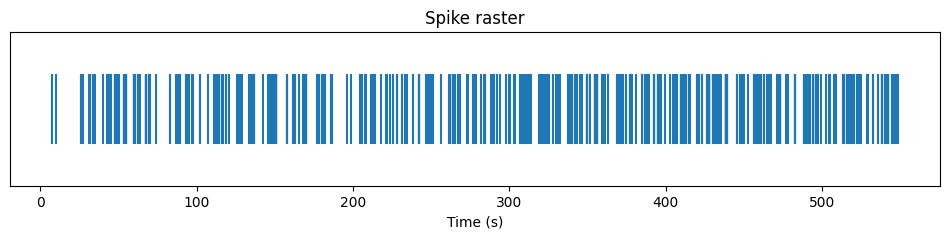

Spike count: 645
First 10 events: [ 28666  34303 111487 140452 141307 146699 160683 187953 236980 241236]


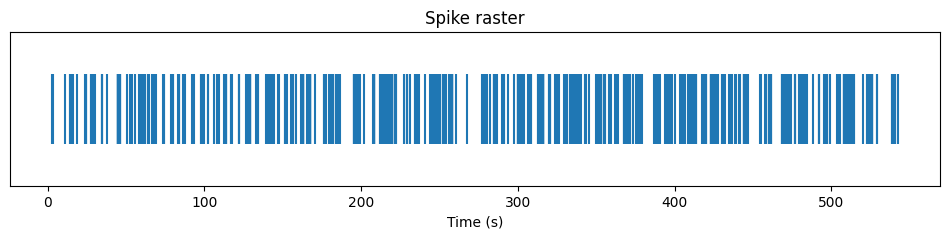

Spike count: 875
First 10 events: [ 5785 17271 17341 17366 18079 46818 94484 94591 97884 98682]


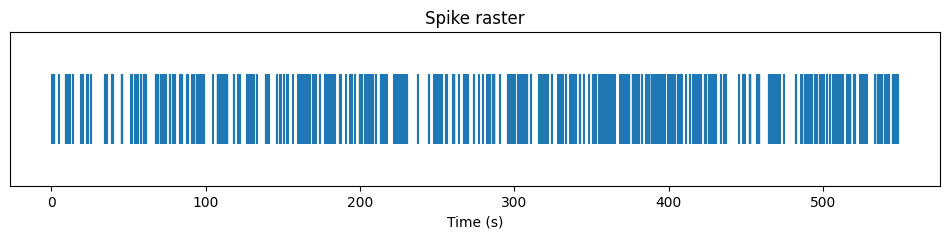

Spike count: 802
First 10 events: [ 3266  3354  5783 11755 17340 17354 44252 44370 62972 63015]


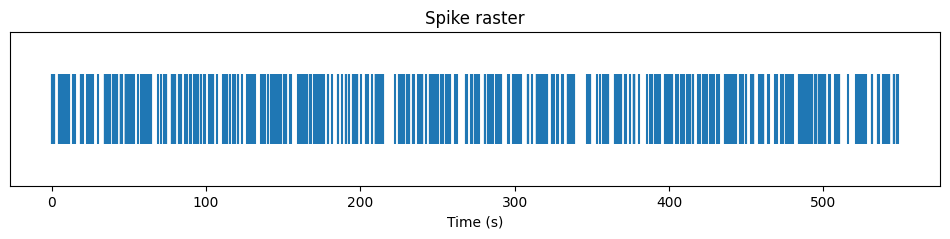

Spike count: 908
First 10 events: [152768 153151 190872 190953 190976 191698 192700 197958 198209 198246]


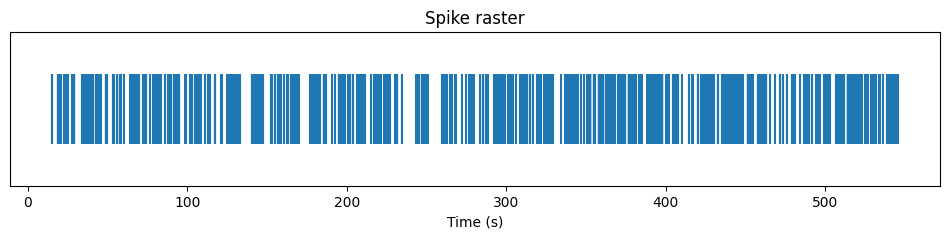

Spike count: 1183
First 10 events: [ 1271  1302 10566 18150 18294 23538 31619 96884 96931 96953]


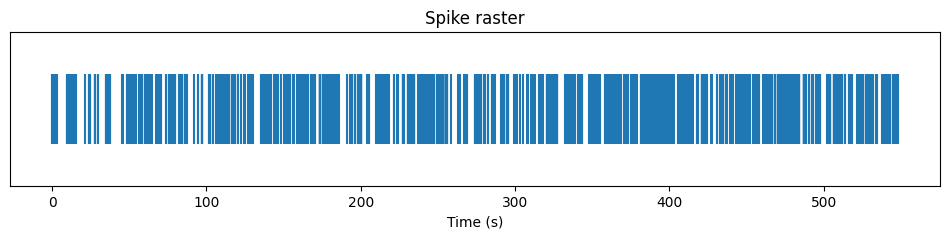

In [10]:
for path in paths_linear_trial:
    

    events, spike_times_sec, hdr = fget_spk_python(path)

    print("Spike count:", len(events))
    print("First 10 events:", events[:10])




    plt.figure(figsize=(12, 2))
    plt.eventplot(spike_times_sec, lineoffsets=1, linelengths=0.8)

    plt.xlabel("Time (s)")
    plt.yticks([])
    plt.title("Spike raster")
    plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


def gaussian_rate_convolution(spike_times, t_start=None, t_end=None, dt=0.001, sigma=0.2):
    """
    Gaussian-smoothed firing rate using binning + convolution.

    spike_times : spike times in seconds
    dt          : bin width in seconds
    sigma       : Gaussian std in seconds

    returns:
        t        : time axis
        rate     : firing rate in spikes/s
        counts   : binned spike counts
    """
    spike_times = np.asarray(spike_times)

    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    bins = np.arange(t_start, t_end + dt, dt)
    counts, edges = np.histogram(spike_times, bins=bins)

    # Convert sigma from seconds to bins
    sigma_bins = sigma / dt

    # Smooth spike counts
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_bins,
        mode="constant"
    )

    # Convert counts/bin to spikes/second
    rate = smoothed_counts / dt

    # Bin centers
    t = edges[:-1] + dt / 2

    return t, rate, counts

In [12]:
#plt.imshow(msq1D.T, aspect='auto', cmap='gray')

# to do 

- STA 
- OPTIMAL KERNEL 

the standard method used to determine the optimal kernel is to measure the spike-triggered average stimulus in response to a white-noise stimulus.

- STATIC NONLINEARITY

- BETTER TUNING CURVE 

- POISSON?????

# Spike-Triggered Average (STA)

In [13]:
n_lags = 25  # frames (~419 ms at 59.72 Hz)


def compute_sta(spike_files, stim, n_lags, frame_rate):
    T, N        = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)       # [1, 2, ..., n_lags]; row 0 = most recent
    sta_accum   = np.zeros((n_lags, N))
    n_total     = 0

    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path) 
        frames = np.floor(spk_sec * frame_rate).astype(int)
        valid  = (frames >= n_lags) & (frames < T)
        frames = frames[valid]

        windows    = frames[:, np.newaxis] - lag_offsets[np.newaxis, :]   # (n_spikes, n_lags)
        sta_accum += stim[windows].sum(axis=0)                            # (n_lags, N)
        n_total   += len(frames)
        

    print(f'\nTotal spikes used: {n_total}')
    return sta_accum / n_total, n_total



In [14]:
print(msq1D_stim.mean())
print(msq1D_stim.mean(axis=0))  # if the mean is approx 0 we dont need to subtract it 

3.051850947599719e-05
[3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05]


In [15]:
sta_linear,  n_linear  = compute_sta(paths_linear_trial,  msq1D_stim, n_lags, frame_rate)
sta_complex, n_complex = compute_sta(paths_comples_trials, msq1D_stim, n_lags, frame_rate)
print(f'STA linear: {n_linear} spikes  |  STA complex: {n_complex} spikes')


Total spikes used: 5635

Total spikes used: 2950
STA linear: 5635 spikes  |  STA complex: 2950 spikes


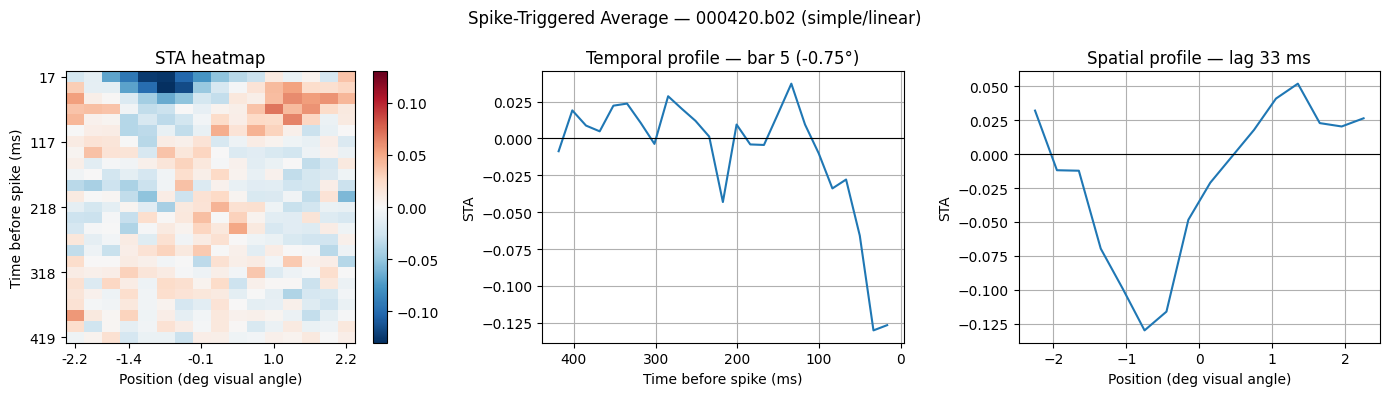

In [16]:
bar_positions = np.linspace(-sti_w_deg / 2, sti_w_deg / 2, 16)
lags_ms       = np.arange(1, n_lags + 1) / frame_rate * 1000

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Spike-Triggered Average — 000420.b02 (simple/linear)')

ax = axes[0]
vmax = np.abs(sta_linear).max()
im   = ax.imshow(sta_linear, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                 interpolation='nearest', origin='upper')
xtick_idx = np.linspace(0, 15, 5).astype(int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([f'{bar_positions[i]:.1f}' for i in xtick_idx])
ax.set_xlabel('Position (deg visual angle)')
ytick_idx = np.linspace(0, n_lags - 1, 5).astype(int)
ax.set_yticks(ytick_idx)
ax.set_yticklabels([f'{lags_ms[i]:.0f}' for i in ytick_idx])
ax.set_ylabel('Time before spike (ms)')
ax.set_title('STA heatmap')
plt.colorbar(im, ax=ax)

ax = axes[1]
peak_bar = int(np.abs(sta_linear).max(axis=0).argmax())
ax.plot(lags_ms, sta_linear[:, peak_bar])
ax.axhline(0, color='k', linewidth=0.8)
ax.invert_xaxis()
ax.set_xlabel('Time before spike (ms)')
ax.set_ylabel('STA')
ax.set_title(f'Temporal profile — bar {peak_bar} ({bar_positions[peak_bar]:.2f}°)')
ax.grid(True)

ax = axes[2]
peak_lag = int(np.abs(sta_linear).max(axis=1).argmax())
ax.plot(bar_positions, sta_linear[peak_lag])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Position (deg visual angle)')
ax.set_ylabel('STA')
ax.set_title(f'Spatial profile — lag {lags_ms[peak_lag]:.0f} ms')
ax.grid(True)

plt.tight_layout()
plt.show()

## STA vs STC — Optimal Feature Extraction

**Spike-Triggered Average (STA)** is the mean stimulus preceding each spike. For white noise it equals the Wiener filter (optimal linear kernel). It captures phase-sensitive, linear receptive fields but averages to near-zero for complex cells whose responses are invariant to stimulus phase.

**Spike-Triggered Covariance (STC)** examines the full second-order statistics of the spike-triggered stimulus ensemble. Eigenvectors of `ΔC = C_spike − C_prior` with large eigenvalues are the stimulus features that drive (positive λ) or suppress (negative λ) the neuron — revealing nonlinear subunits invisible to the STA.

| Method | Captures | Best for |
|---|---|---|
| STA | Linear RF — phase-sensitive | Simple/linear cells |
| STC | Nonlinear subunits — phase-invariant | Complex cells |

**CV metric:** Pearson r between predicted rate and Gaussian-smoothed spike train of held-out run (σ = 3 frames ≈ 50 ms).  
**STC energy model prediction:** `r(t) = Σ_k [x(t) · v_k]²` summed over the top K eigenvectors.

In [17]:
def build_design_matrix(stim, n_lags):
    T, N = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)
    t_idx = np.arange(n_lags, T)
    wins  = t_idx[:, np.newaxis] - lag_offsets[np.newaxis, :]
    return stim[wins].astype(np.float64).reshape(len(t_idx), n_lags * N)


def compute_stc(spike_files, stim, n_lags, frame_rate, X_flat, C_prior):
    T, N = stim.shape

    spk_wins = []
    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path)
        frames = np.floor(spk_sec * frame_rate).astype(int)
        frames = frames[(frames >= n_lags) & (frames < T)]
        spk_wins.append(X_flat[frames - n_lags])

    X_spk  = np.vstack(spk_wins)
    n_spk  = len(X_spk)
    C_spk  = (X_spk.T @ X_spk) / n_spk
    delta_C = C_spk - C_prior

    eigvals, eigvecs = np.linalg.eigh(delta_C)
    order      = np.argsort(np.abs(eigvals))[::-1]
    eigvals    = eigvals[order]
    eigvecs_2d = eigvecs[:, order].T.reshape(-1, n_lags, N)

    return eigvals, eigvecs_2d, n_spk

In [18]:
T, N_bars = msq1D_stim.shape
T_eff = T - n_lags

print('Building design matrix ...')
X_flat  = build_design_matrix(msq1D_stim, n_lags)
C_prior = (X_flat.T @ X_flat) / T_eff
print(f'  X_flat: {X_flat.shape}  ({X_flat.nbytes // 1024 // 1024} MB)')

print('\nSTC — complex cell ...')
eigvals_c, eigvecs_c, _ = compute_stc(paths_comples_trials, msq1D_stim, n_lags, frame_rate, X_flat, C_prior)
print('STC — simple cell ...')
eigvals_l, eigvecs_l, _ = compute_stc(paths_linear_trial,  msq1D_stim, n_lags, frame_rate, X_flat, C_prior)
print('done.')

Building design matrix ...


  X_flat: (32742, 400)  (99 MB)

STC — complex cell ...
STC — simple cell ...


done.


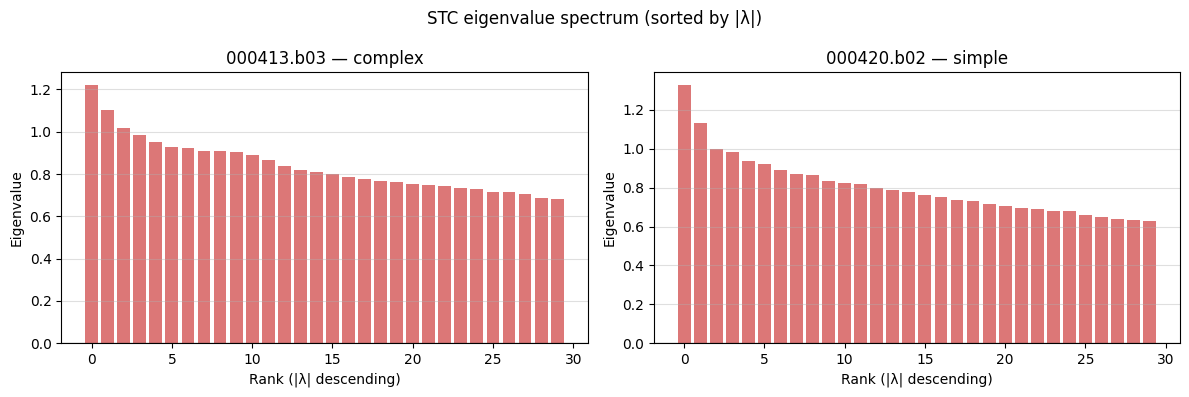

In [19]:
K_show = 30

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('STC eigenvalue spectrum (sorted by |λ|)')

for ax, eigvals, label in zip(
        axes,
        [eigvals_c, eigvals_l],
        ['000413.b03 — complex', '000420.b02 — simple']):
    idx    = np.arange(K_show)
    colors = ['#D65F5F' if v > 0 else '#4878CF' for v in eigvals[:K_show]]
    ax.bar(idx, eigvals[:K_show], color=colors, alpha=0.85)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_xlabel('Rank (|λ| descending)')
    ax.set_ylabel('Eigenvalue')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

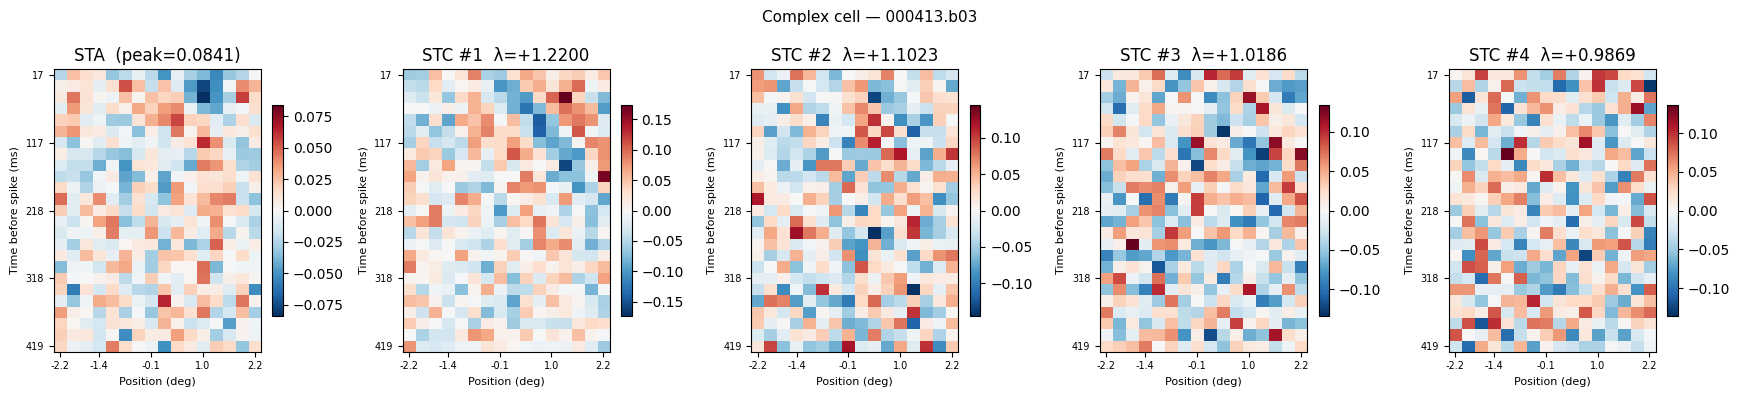

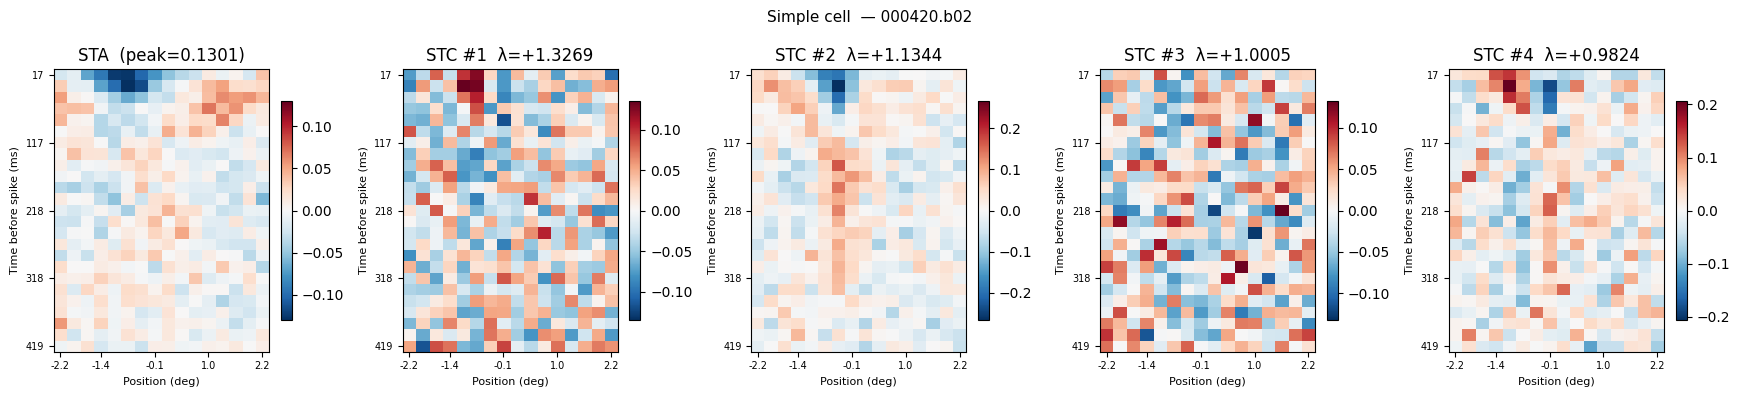

In [20]:
K_filt = 4


def _label_ax(ax, bar_positions, lags_ms, n_lags):
    xtick_idx = np.linspace(0, 15, 5).astype(int)
    ax.set_xticks(xtick_idx)
    ax.set_xticklabels([f'{bar_positions[i]:.1f}' for i in xtick_idx], fontsize=7)
    ax.set_xlabel('Position (deg)', fontsize=8)
    ytick_idx = np.linspace(0, n_lags - 1, 5).astype(int)
    ax.set_yticks(ytick_idx)
    ax.set_yticklabels([f'{lags_ms[i]:.0f}' for i in ytick_idx], fontsize=7)
    ax.set_ylabel('Time before spike (ms)', fontsize=8)


def plot_sta_stc(sta, eigvals, eigvecs, bar_positions, lags_ms, n_lags, title, K=K_filt):
    fig, axes = plt.subplots(1, 1 + K, figsize=(3.5 * (1 + K), 4))
    fig.suptitle(title, fontsize=11)

    vmax = np.abs(sta).max()
    im   = axes[0].imshow(sta, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                          interpolation='nearest', origin='upper')
    _label_ax(axes[0], bar_positions, lags_ms, n_lags)
    axes[0].set_title(f'STA  (peak={vmax:.4f})')
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    for k in range(K):
        filt   = eigvecs[k]
        vmax_k = np.abs(filt).max()
        im     = axes[k+1].imshow(filt, aspect='auto', cmap='RdBu_r',
                                  vmin=-vmax_k, vmax=vmax_k,
                                  interpolation='nearest', origin='upper')
        _label_ax(axes[k+1], bar_positions, lags_ms, n_lags)
        sign = '+' if eigvals[k] > 0 else '−'
        axes[k+1].set_title(f'STC #{k+1}  λ={sign}{abs(eigvals[k]):.4f}')
        plt.colorbar(im, ax=axes[k+1], fraction=0.046)

    plt.tight_layout()
    plt.show()


plot_sta_stc(sta_complex, eigvals_c, eigvecs_c, bar_positions, lags_ms, n_lags,
             'Complex cell — 000413.b03')
plot_sta_stc(sta_linear,  eigvals_l, eigvecs_l, bar_positions, lags_ms, n_lags,
             'Simple cell  — 000420.b02')

In [21]:
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter1d

K_cv     = 4
sigma_sm = 3  # frames ≈ 50 ms at ~60 Hz


def cv_sta_stc(spike_files, stim, n_lags, frame_rate, X_flat, C_prior, K=4, sigma_smooth=3):
    T     = stim.shape[0]
    T_eff = X_flat.shape[0]
    n_runs = len(spike_files)

    run_ys = []
    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path)
        frames = np.floor(spk_sec * frame_rate).astype(int)
        frames = frames[(frames >= n_lags) & (frames < T)] - n_lags
        y = np.zeros(T_eff, dtype=np.float32)
        np.add.at(y, frames, 1)
        run_ys.append(y)
    run_ys    = np.stack(run_ys)
    run_rates = np.stack([gaussian_filter1d(y.astype(float), sigma_smooth) for y in run_ys])
    Xty       = np.stack([X_flat.T @ run_ys[i] for i in range(n_runs)])

    sta_rs, stc_rs = [], []

    for test_i in range(n_runs):
        train_idx = [i for i in range(n_runs) if i != test_i]

        # STA predictor (whitened for white noise → just STA / n_train_spikes)
        n_train = run_ys[train_idx].sum()
        w_sta   = Xty[train_idx].sum(axis=0) / (n_train + 1e-10)
        sta_rs.append(pearsonr(X_flat @ w_sta, run_rates[test_i]).statistic)

        # STC energy predictor
        spk_wins = []
        for i in train_idx:
            idx_spk = np.where(run_ys[i] > 0)[0]
            idx_spk = np.repeat(idx_spk, run_ys[i, idx_spk].astype(int))
            spk_wins.append(X_flat[idx_spk])
        X_spk_tr = np.vstack(spk_wins).astype(np.float64)

        C_sp    = (X_spk_tr.T @ X_spk_tr) / len(X_spk_tr)
        ev, evec = np.linalg.eigh(C_sp - C_prior)
        order   = np.argsort(np.abs(ev))[::-1]
        top_v   = evec[:, order[:K]]            # (D, K)

        energy  = (X_flat @ top_v) ** 2        # (T_eff, K)
        stc_rs.append(pearsonr(energy.sum(axis=1), run_rates[test_i]).statistic)

        print(f'  fold {test_i}: STA r={sta_rs[-1]:.4f}   STC r={stc_rs[-1]:.4f}')

    return np.array(sta_rs), np.array(stc_rs)


print('=== Complex cell — 000413.b03 ===')
sta_rs_c, stc_rs_c = cv_sta_stc(paths_comples_trials, msq1D_stim, n_lags, frame_rate,
                                 X_flat, C_prior, K=K_cv, sigma_smooth=sigma_sm)
print(f'STA r = {sta_rs_c.mean():.4f} ± {sta_rs_c.std():.4f}')
print(f'STC r = {stc_rs_c.mean():.4f} ± {stc_rs_c.std():.4f}')

print('\n=== Simple cell — 000420.b02 ===')
sta_rs_l, stc_rs_l = cv_sta_stc(paths_linear_trial, msq1D_stim, n_lags, frame_rate,
                                 X_flat, C_prior, K=K_cv, sigma_smooth=sigma_sm)
print(f'STA r = {sta_rs_l.mean():.4f} ± {sta_rs_l.std():.4f}')
print(f'STC r = {stc_rs_l.mean():.4f} ± {stc_rs_l.std():.4f}')

=== Complex cell — 000413.b03 ===
  fold 0: STA r=0.0242   STC r=0.0377


  fold 1: STA r=0.0098   STC r=0.0105
  fold 2: STA r=0.0127   STC r=0.0198


  fold 3: STA r=0.0244   STC r=0.0164
  fold 4: STA r=0.0147   STC r=0.0317
STA r = 0.0172 ± 0.0061
STC r = 0.0232 ± 0.0100

=== Simple cell — 000420.b02 ===


  fold 0: STA r=0.0432   STC r=0.0958
  fold 1: STA r=0.0527   STC r=0.0806


  fold 2: STA r=0.0723   STC r=0.1039
  fold 3: STA r=0.0462   STC r=0.0754


  fold 4: STA r=0.0445   STC r=0.0983
  fold 5: STA r=0.0541   STC r=0.0621


  fold 6: STA r=0.0373   STC r=0.0617
STA r = 0.0501 ± 0.0105
STC r = 0.0825 ± 0.0160


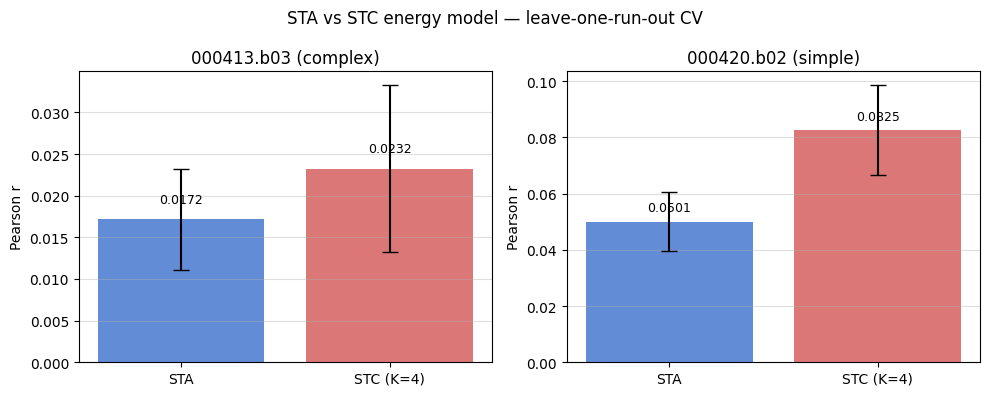

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('STA vs STC energy model — leave-one-run-out CV', fontsize=12)

for ax, (sta_rs, stc_rs), label in zip(
        axes,
        [(sta_rs_c, stc_rs_c), (sta_rs_l, stc_rs_l)],
        ['000413.b03 (complex)', '000420.b02 (simple)']):
    means = [sta_rs.mean(), stc_rs.mean()]
    stds  = [sta_rs.std(),  stc_rs.std()]
    bars  = ax.bar([f'STA', f'STC (K={K_cv})'], means, yerr=stds, capsize=6,
                   color=['#4878CF', '#D65F5F'], alpha=0.85)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, m + max(stds) * 0.15 + 1e-4,
                f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pearson r')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()